# Search-based Test Suite Generation (SuT: `MnistCNN`)

In this exercise, we'll implement a simple **search-based test suite generation** method that searches the input space and keeps tests that improve neuron coverages of `MnistCNN`.

In [1]:
import os, sys

# exercises → unit folder → modules → project_root
MODULES_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
CODE_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "code")
MODEL_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "model")
DATA_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "data")

if CODE_DIR not in sys.path:
    sys.path.append(CODE_DIR)

if MODEL_DIR not in sys.path:
    sys.path.append(MODEL_DIR)

if DATA_DIR not in sys.path:
    sys.path.append(DATA_DIR)

print("Added to sys.path:", CODE_DIR)
print("Added to sys.path:", MODEL_DIR)
print("Added to sys.path:", DATA_DIR)

Added to sys.path: /workspace/modules/exercise_artifacts/code
Added to sys.path: /workspace/modules/exercise_artifacts/model
Added to sys.path: /workspace/modules/exercise_artifacts/data


In [2]:
# Load pre-saved MNIST model
import torch
from mnist_model import load_trained_model
from torchinfo import summary

device = "cuda" if torch.cuda.is_available() else "cpu"

WEIGHTS_PATH = os.path.join(MODEL_DIR, "mnist_model_weights.pt")

model = load_trained_model(WEIGHTS_PATH, device=device)

print("MnistCNN Summary:")
summary(model, input_size=(1, 1, 28, 28), col_names=["input_size", "output_size", "num_params"])

MnistCNN Summary:


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
MnistCNN                                 [1, 1, 28, 28]            [1, 10]                   --
├─Conv2d: 1-1                            [1, 1, 28, 28]            [1, 8, 28, 28]            80
├─Conv2d: 1-2                            [1, 8, 14, 14]            [1, 16, 14, 14]           1,168
├─Linear: 1-3                            [1, 784]                  [1, 32]                   25,120
├─Linear: 1-4                            [1, 32]                   [1, 10]                   330
Total params: 26,698
Trainable params: 26,698
Non-trainable params: 0
Total mult-adds (M): 0.32
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.11
Estimated Total Size (MB): 0.19

In [3]:
# Load pre-saved MNIST subsets (using DATA_DIR defined above)
test_data = torch.load(os.path.join(DATA_DIR, "mnist_test_200.pt"))

test_images, test_labels = test_data["images"], test_data["labels"]

print(f"Test:  {test_images.shape}, {test_labels.shape}")

Test:  torch.Size([200, 1, 28, 28]), torch.Size([200])


In [4]:
from neuron_coverages import neuron_coverage, top_k_neuron_coverage
from mnist_instrumentation import forward_and_capture_relu

## Representing a Test Suite as an **Individual** Solution

We represent a test suite as one candidate solution that can be evolved and compared during search.

Seed suite size: 10
One test image shape: torch.Size([1, 28, 28])


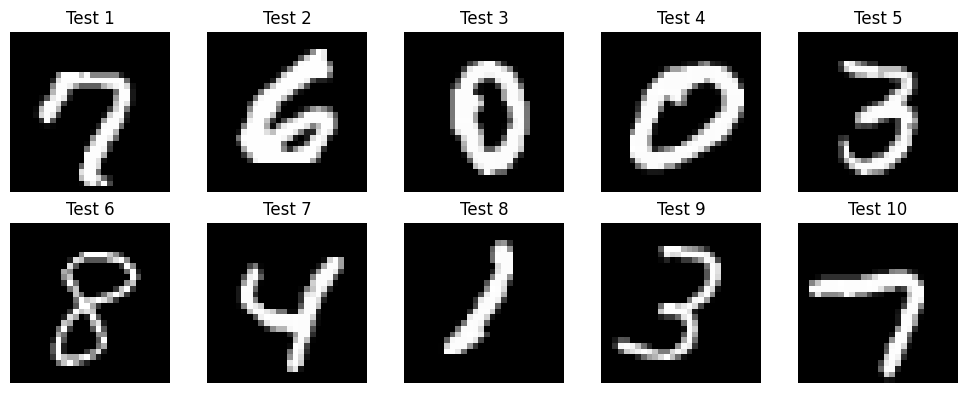

In [5]:
import random
from typing import Callable, List

import matplotlib.pyplot as plt

ImageTensor = torch.Tensor
TestSuite = List[ImageTensor]


def generate_random_seed_individual(length: int = 10, source_images: torch.Tensor = test_images) -> TestSuite:
    """Sample one candidate test suite (individual) with unique images."""
    if length <= 0:
        raise ValueError("length must be positive.")
    if length > len(source_images):
        raise ValueError("length cannot exceed the number of available source images.")

    sampled_indices = random.sample(range(len(source_images)), k=length)
    return [source_images[idx].clone() for idx in sampled_indices]


seed_suite = generate_random_seed_individual(length=10)
print(f"Seed suite size: {len(seed_suite)}")
print(f"One test image shape: {seed_suite[0].shape}")

# Visualize the 10-image seed test suite.
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img = seed_suite[i].squeeze().cpu().numpy()
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Test {i + 1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Coverage as the Objective Functions

When the final objective is **maximizing neuron coverages**, we can still shape the fitness to improve search behavior.

We'll directly use neuron and top-k neuron coverages as fitness functions.


In [6]:
# Implement fitness functions (neuron coverage and top-k neuron coverage)

def suite_to_batch(suite: TestSuite) -> torch.Tensor:
    """Convert list-based suite representation to a model-ready batch tensor."""
    if len(suite) == 0:
        raise ValueError("suite must contain at least one test image.")
    return torch.stack([img.clone() for img in suite], dim=0).to(device)


def fitness_neuron_coverage(suite: TestSuite, threshold: float = 0.0) -> float:
    with torch.no_grad():
        _, activations = forward_and_capture_relu(model, suite_to_batch(suite), to_cpu=True)
    score, _ = neuron_coverage(activations, threshold=threshold)
    return float(score)


def fitness_topk_neuron_coverage(suite: TestSuite, k: float = 0.1) -> float:
    with torch.no_grad():
        _, activations = forward_and_capture_relu(model, suite_to_batch(suite), to_cpu=True)
    score, _ = top_k_neuron_coverage(activations, k=k, per_filter=True)
    return float(score)


fitness_map: dict[int, Callable[[TestSuite], float]] = {
    1: fitness_neuron_coverage,
    2: fitness_topk_neuron_coverage,
}

print("Initial fitness (seed suite):")
print(f"- NC   : {fitness_neuron_coverage(seed_suite):.4f}")
print(f"- TKNC : {fitness_topk_neuron_coverage(seed_suite):.4f}")

Initial fitness (seed suite):
- NC   : 0.7618
- TKNC : 0.3662


## Define unit operators for search

- Random population generation
- Mutation operators
- Crossover operator
- Selection operator

### Random population generation

We pick random images in the source test images.

In [7]:
def initialize_population(pop_size: int = 20, suite_len: int = 10) -> List[TestSuite]:
    """Create an initial population of random candidate suites."""
    if pop_size <= 0:
        raise ValueError("pop_size must be positive.")
    return [generate_random_seed_individual(length=suite_len) for _ in range(pop_size)]


population = initialize_population(pop_size=20, suite_len=10)
print(f"Initialized population size: {len(population)}")
print(f"Each individual length: {len(population[0])}")

Initialized population size: 20
Each individual length: 10


### Mutation operators

We'll reuse the mutation operators used in the fuzzing exercises.

In [8]:
import torchvision.transforms.functional as TF

def gaussian_noise(image, std=0.1):
    """Add Gaussian noise to the image."""
    noise = torch.randn_like(image) * std
    return torch.clamp(image + noise, 0, 1)

def brightness_shift(image, max_shift=0.2):
    """Randomly shift brightness."""
    shift = (torch.rand(1).item() - 0.5) * 2 * max_shift  # [-max_shift, max_shift]
    return torch.clamp(image + shift, 0, 1)

def small_rotation(image, max_angle=20):
    """Apply small random rotation."""
    angle = (torch.rand(1).item() - 0.5) * 2 * max_angle  # [-max_angle, max_angle]
    # TF.rotate expects [C, H, W] format
    return TF.rotate(image, angle)

def pixel_dropout(image, dropout_rate=0.05):
    """Randomly drop pixels (set to 0)."""
    mask = torch.rand_like(image) > dropout_rate  # True = keep, False = drop
    return image * mask


# Define mutations
mutations = [
    ("Original", lambda x: x),
    ("Noise", gaussian_noise),
    ("Brightness", brightness_shift),
    ("Rotation", small_rotation),
    ("Dropout", pixel_dropout),
]

### Crossover operator

We'll reuse the crossover operator that swaps the two indivisuals at the random index.

In [9]:
def crossover(parent1: TestSuite, parent2: TestSuite) -> tuple[TestSuite, TestSuite]:
    """One-point crossover between two suites of equal length."""
    if len(parent1) != len(parent2):
        raise ValueError("Both parents must have the same suite length.")
    if len(parent1) < 2:
        return [img.clone() for img in parent1], [img.clone() for img in parent2]

    cut = random.randint(1, len(parent1) - 1)
    child1 = [img.clone() for img in parent1[:cut]] + [img.clone() for img in parent2[cut:]]
    child2 = [img.clone() for img in parent2[:cut]] + [img.clone() for img in parent1[cut:]]
    return child1, child2


p1 = generate_random_seed_individual(length=10)
p2 = generate_random_seed_individual(length=10)
c1, c2 = crossover(p1, p2)
print(f"Crossover done | len(child1)={len(c1)}, len(child2)={len(c2)}")

Crossover done | len(child1)=10, len(child2)=10


### Selection operator

We keep using the selection operator that fitters strong half indivisuals in the population.

In [10]:
def mutate_suite(suite: TestSuite) -> TestSuite:
    """Mutate one randomly selected test image in a suite."""
    mutated = [img.clone() for img in suite]
    case_idx = random.randrange(len(mutated))
    op_name, op = random.choice(mutations[1:])  # skip identity mutation
    mutated[case_idx] = torch.clamp(op(mutated[case_idx]), 0.0, 1.0)
    return mutated


def select_top_half(population: List[TestSuite], fitness_fn: Callable[[TestSuite], float]) -> List[TestSuite]:
    """Sort population by fitness and keep top half."""
    scored = [(fitness_fn(ind), ind) for ind in population]
    scored.sort(key=lambda x: x[0], reverse=True)
    keep_n = max(1, len(population) // 2)
    return [ind for _, ind in scored[:keep_n]]


selected = select_top_half(population, fitness_neuron_coverage)
print(f"Selected survivors (top half): {len(selected)} / {len(population)}")

Selected survivors (top half): 10 / 20


## Define and run search algorithms

- Hill-climbing algorithm
- Genetic algorithm

### Hill climbing algorithm

In [11]:
def hill_climbing(
    init_suite: TestSuite,
    fitness_id: int = 1,
    k: int = 8,
    budget: int = 100,
    log_every: int = 10,
):
    """Best-of-k neighborhood hill climbing for test suite optimization."""
    if fitness_id not in fitness_map:
        raise ValueError("fitness_id must be one of {1, 2}.")

    fitness_fn = fitness_map[fitness_id]

    # Initialize current and best solution from the same seed suite.
    current = [img.clone() for img in init_suite]
    current_score = fitness_fn(current)
    best_suite = [img.clone() for img in current]
    best_score = current_score

    # Track best-so-far score per step (monotonic history).
    history = [best_score]

    for step in range(1, budget + 1):
        # 1) Sample k neighbors from the current suite via mutation.
        best_neighbor = None
        best_neighbor_score = float("-inf")

        for _ in range(k):
            neighbor = mutate_suite(current)
            score = fitness_fn(neighbor)
            if score > best_neighbor_score:
                best_neighbor = neighbor
                best_neighbor_score = score

        # 2) Greedy move: update current only when improvement exists.
        if best_neighbor is not None and best_neighbor_score > current_score:
            current = best_neighbor
            current_score = best_neighbor_score
            if current_score > best_score:
                best_suite = [img.clone() for img in current]
                best_score = current_score

        history.append(best_score)
        if step % log_every == 0 or step == budget:
            print(f"[HC] Step {step}/{budget} | best={best_score:.4f}")

    return best_suite, best_score, history


[HC] Step 20/100 | best=0.9155
[HC] Step 40/100 | best=0.9155
[HC] Step 60/100 | best=0.9156
[HC] Step 80/100 | best=0.9156
[HC] Step 100/100 | best=0.9156
[HC] Step 20/100 | best=0.3581
[HC] Step 40/100 | best=0.3778
[HC] Step 60/100 | best=0.3909
[HC] Step 80/100 | best=0.4083
[HC] Step 100/100 | best=0.4347


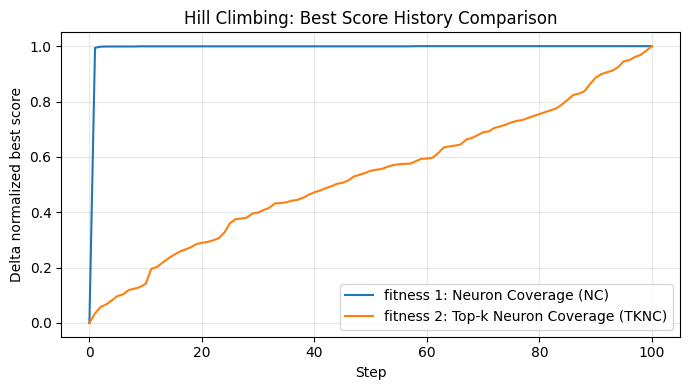

Hill-climbing final metrics by fitness choice:
- fitness 1 (Neuron Coverage (NC)): best_score=0.9156, NC=0.9156, TKNC=0.3358
- fitness 2 (Top-k Neuron Coverage (TKNC)): best_score=0.4347, NC=0.9153, TKNC=0.4347


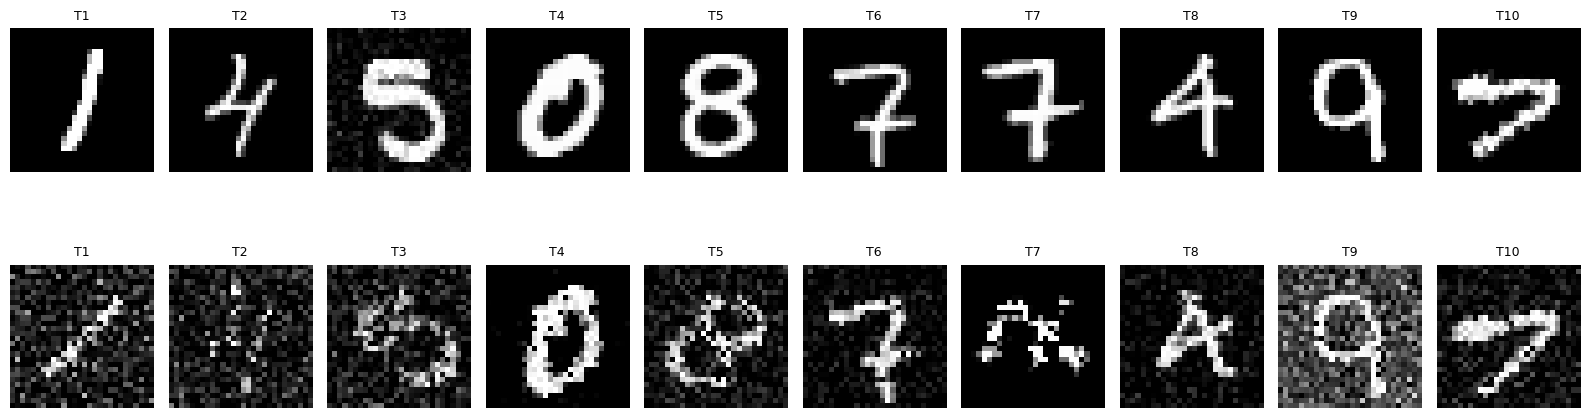

In [12]:
# Run Hill-climbing algorithm with both fitness choices and compare results
random.seed(42)
torch.manual_seed(42)

fitness_ids = [1, 2]
fitness_labels = {
    1: "Neuron Coverage (NC)",
    2: "Top-k Neuron Coverage (TKNC)",
}
colors = {1: "tab:blue", 2: "tab:orange"}

init_suite = generate_random_seed_individual(length=10)
all_hc_results = {}

for fid in fitness_ids:
    hc_suite, hc_score, hc_history = hill_climbing(
        init_suite=init_suite,
        fitness_id=fid,
        k=10,
        budget=100,
        log_every=20,
    )
    all_hc_results[fid] = {
        "best_suite": hc_suite,
        "best_score": hc_score,
        "history": hc_history,
        "final_nc": fitness_neuron_coverage(hc_suite),
        "final_tknc": fitness_topk_neuron_coverage(hc_suite),
    }


def _minmax_scores_aligned(scores):
    """Per-run min-max normalize to [0,1], then align step-0 at 0."""
    mn, mx = min(scores), max(scores)
    span = mx - mn
    if span <= 1e-15:
        return [0.0 for _ in scores]
    normed = [(s - mn) / span for s in scores]
    z0 = normed[0]
    return [x - z0 for x in normed]


# Compare score histories across two fitness objectives.
plt.figure(figsize=(7, 4))
for fid in fitness_ids:
    aligned = _minmax_scores_aligned(all_hc_results[fid]["history"])
    plt.plot(aligned, label=f"fitness {fid}: {fitness_labels[fid]}", color=colors[fid])

plt.title("Hill Climbing: Best Score History Comparison")
plt.xlabel("Step")
plt.ylabel("Delta normalized best score")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Hill-climbing final metrics by fitness choice:")
for fid in fitness_ids:
    r = all_hc_results[fid]
    print(
        f"- fitness {fid} ({fitness_labels[fid]}): "
        f"best_score={r['best_score']:.4f}, NC={r['final_nc']:.4f}, TKNC={r['final_tknc']:.4f}"
    )

# Visualize final optimized suites side-by-side (one row per fitness choice).
fig, axes = plt.subplots(len(fitness_ids), 10, figsize=(16, 2.8 * len(fitness_ids)))
if len(fitness_ids) == 1:
    axes = [axes]

for row, fid in enumerate(fitness_ids):
    suite = all_hc_results[fid]["best_suite"]
    for col in range(10):
        ax = axes[row][col]
        ax.imshow(suite[col].squeeze().cpu().numpy(), cmap="gray")
        if col == 0:
            ax.set_ylabel(f"HC f{fid}", rotation=0, labelpad=25, va="center")
        ax.set_title(f"T{col + 1}", fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.show()

### Run genetic algorithm and visualize the results

In [13]:
def genetic_algorithm(
    fitness_id: int = 1,
    pop_size: int = 20,
    suite_len: int = 10,
    max_epoch: int = 100,
    crossover_fraction: float = 0.6,
    mutation_fraction: float = 0.5,
    log_every: int = 5,
):
    """Simple GA with epoch order: selection -> record -> refill -> crossover -> mutation."""
    if fitness_id not in fitness_map:
        raise ValueError("fitness_id must be one of {1, 2}.")

    fitness_fn = fitness_map[fitness_id]
    population = initialize_population(pop_size=pop_size, suite_len=suite_len)

    # Best-so-far trackers across all epochs.
    best_overall = None
    best_overall_score = float("-inf")
    score_history = []

    for epoch in range(1, max_epoch + 1):
        # 1) Selection: keep top half from the current population.
        survivors = select_top_half(population, fitness_fn)

        # 2) Record epoch best and update global best-so-far.
        scored_survivors = sorted([(fitness_fn(ind), ind) for ind in survivors], key=lambda x: x[0], reverse=True)
        epoch_best_score, epoch_best_suite = scored_survivors[0]

        if epoch_best_score > best_overall_score:
            best_overall_score = epoch_best_score
            best_overall = [img.clone() for img in epoch_best_suite]

        # Best-so-far history (monotonic).
        score_history.append(best_overall_score)

        # 3) Refill dead half with fresh random individuals.
        refill_n = pop_size - len(survivors)
        refilled = initialize_population(pop_size=refill_n, suite_len=suite_len)
        next_generation = [[img.clone() for img in ind] for ind in (survivors + refilled)]

        # 4) Apply crossover to a random fraction of population.
        n_cross = int(pop_size * crossover_fraction)
        if n_cross % 2 == 1:
            n_cross -= 1
        if n_cross >= 2:
            cross_indices = random.sample(range(pop_size), n_cross)
            random.shuffle(cross_indices)
            for i in range(0, n_cross, 2):
                idx1, idx2 = cross_indices[i], cross_indices[i + 1]
                child1, child2 = crossover(next_generation[idx1], next_generation[idx2])
                next_generation[idx1] = child1
                next_generation[idx2] = child2

        # 5) Apply mutation to a random fraction of population.
        n_mut = int(pop_size * mutation_fraction)
        if n_mut > 0:
            mutate_indices = random.sample(range(pop_size), n_mut)
            for idx in mutate_indices:
                next_generation[idx] = mutate_suite(next_generation[idx])

        population = next_generation

        if epoch % log_every == 0 or epoch == max_epoch:
            print(f"[GA] Epoch {epoch}/{max_epoch} | best={best_overall_score:.4f}")

    return best_overall, best_overall_score, score_history


[GA] Epoch 10/100 | best=0.9153
[GA] Epoch 20/100 | best=0.9153
[GA] Epoch 30/100 | best=0.9153
[GA] Epoch 40/100 | best=0.9153
[GA] Epoch 50/100 | best=0.9154
[GA] Epoch 60/100 | best=0.9154
[GA] Epoch 70/100 | best=0.9154
[GA] Epoch 80/100 | best=0.9154
[GA] Epoch 90/100 | best=0.9154
[GA] Epoch 100/100 | best=0.9154
[GA] Epoch 10/100 | best=0.3847
[GA] Epoch 20/100 | best=0.3949
[GA] Epoch 30/100 | best=0.3990
[GA] Epoch 40/100 | best=0.3990
[GA] Epoch 50/100 | best=0.3990
[GA] Epoch 60/100 | best=0.4038
[GA] Epoch 70/100 | best=0.4038
[GA] Epoch 80/100 | best=0.4038
[GA] Epoch 90/100 | best=0.4051
[GA] Epoch 100/100 | best=0.4051


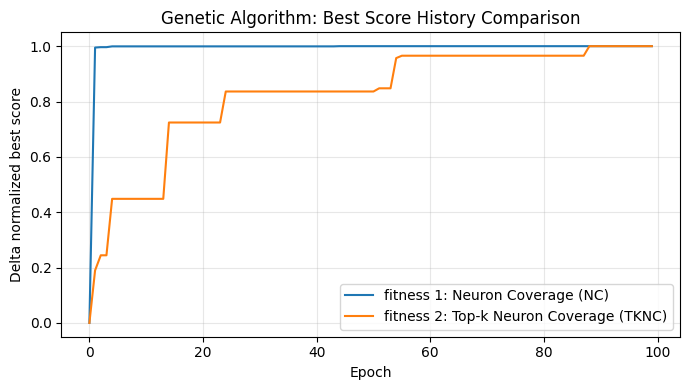

Genetic algorithm final metrics by fitness choice:
- fitness 1 (Neuron Coverage (NC)): best_score=0.9154, NC=0.9154, TKNC=0.3603
- fitness 2 (Top-k Neuron Coverage (TKNC)): best_score=0.4051, NC=0.8877, TKNC=0.4051


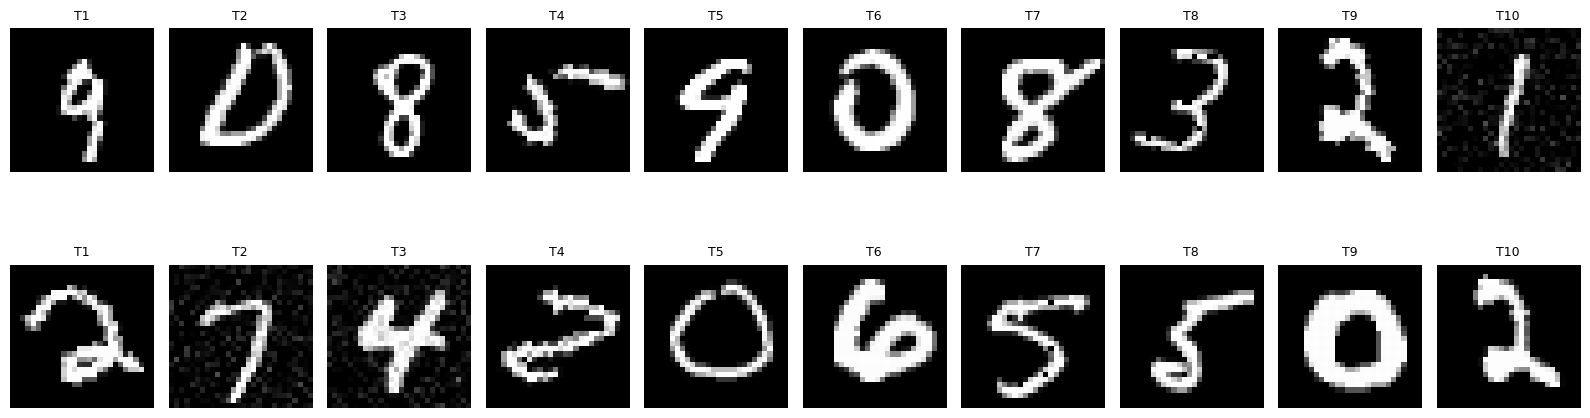


Saved optimized 10-image testsuite in variable: final_suite (len=10)


In [14]:
# Run genetic algorithm with both fitness choices and compare results
random.seed(42)
torch.manual_seed(42)

fitness_ids = [1, 2]
fitness_labels = {
    1: "Neuron Coverage (NC)",
    2: "Top-k Neuron Coverage (TKNC)",
}
colors = {1: "tab:blue", 2: "tab:orange"}

all_ga_results = {}
for fid in fitness_ids:
    best_suite, best_score, ga_history = genetic_algorithm(
        fitness_id=fid,
        pop_size=20,
        suite_len=10,
        max_epoch=100,
        crossover_fraction=0.6,
        mutation_fraction=0.5,
        log_every=10,
    )
    all_ga_results[fid] = {
        "best_suite": best_suite,
        "best_score": best_score,
        "history": ga_history,
        "final_nc": fitness_neuron_coverage(best_suite),
        "final_tknc": fitness_topk_neuron_coverage(best_suite),
    }


# Compare score histories across two fitness objectives.
plt.figure(figsize=(7, 4))
for fid in fitness_ids:
    aligned = _minmax_scores_aligned(all_ga_results[fid]["history"])
    plt.plot(aligned, label=f"fitness {fid}: {fitness_labels[fid]}", color=colors[fid])

plt.title("Genetic Algorithm: Best Score History Comparison")
plt.xlabel("Epoch")
plt.ylabel("Delta normalized best score")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Genetic algorithm final metrics by fitness choice:")
for fid in fitness_ids:
    r = all_ga_results[fid]
    print(
        f"- fitness {fid} ({fitness_labels[fid]}): "
        f"best_score={r['best_score']:.4f}, NC={r['final_nc']:.4f}, TKNC={r['final_tknc']:.4f}"
    )

# Visualize final optimized suites side-by-side (one row per fitness choice).
fig, axes = plt.subplots(len(fitness_ids), 10, figsize=(16, 2.8 * len(fitness_ids)))
if len(fitness_ids) == 1:
    axes = [axes]

for row, fid in enumerate(fitness_ids):
    suite = all_ga_results[fid]["best_suite"]
    for col in range(10):
        ax = axes[row][col]
        ax.imshow(suite[col].squeeze().cpu().numpy(), cmap="gray")
        if col == 0:
            ax.set_ylabel(f"GA f{fid}", rotation=0, labelpad=25, va="center")
        ax.set_title(f"T{col + 1}", fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.show()

# Keep one GA suite as default output (fitness 2: TKNC objective).
final_suite = all_ga_results[2]["best_suite"]
print(f"\nSaved optimized 10-image testsuite in variable: final_suite (len={len(final_suite)})")